In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('Shipment Company.csv')
data

,order_id,customer_id,employee_id,order_date,required_date,shipped_date,ship_via,freight,ship_name,ship_address,...,ship_postal_code,ship_country,shipper_id,company_name,phone,order_id-2,product_id,unit_price,quantity,discount
0,10248,VINET,5,1996-07-04,1996-08-01,1996-07-16,3,32.38,Vins et alcools Chevalier,59 rue de l'Abbaye,...,51100,France,3,Federal Shipping,(503) 555-9931,10248,11,14.00,12,0.00
1,10248,VINET,5,1996-07-04,1996-08-01,1996-07-16,3,32.38,Vins et alcools Chevalier,59 rue de l'Abbaye,...,51100,France,3,Federal Shipping,(503) 555-9931,10248,42,9.80,10,0.00
2,10248,VINET,5,1996-07-04,1996-08-01,1996-07-16,3,32.38,Vins et alcools Chevalier,59 rue de l'Abbaye,...,51100,France,3,Federal Shipping,(503) 555-9931,10248,72,34.80,5,0.00
3,10249,TOMSP,6,1996-07-05,1996-08-16,1996-07-10,1,11.61,Toms Spezialitäten,Luisenstr. 48,...,44087,Germany,1,Speedy Express,(503) 555-9831,10249,14,18.60,9,0.00
4,10249,TOMSP,6,1996-07-05,1996-08-16,1996-07-10,1,11.61,Toms Spezialitäten,Luisenstr. 48,...,44087,Germany,1,Speedy Express,(503) 555-9831,10249,51,42.40,40,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2150,11077,RATTC,1,1998-05-06,1998-06-03,NaN,2,8.53,Rattlesnake Canyon Grocery,2817 Milton Dr.,...,87110,USA,2,United Package,(503) 555-3199,11077,64,33.25,2,0.03
2151,11077,RATTC,1,1998-05-06,1998-06-03,NaN,2,8.53,Rattlesnake Canyon Grocery,2817 Milton Dr.,...,87110,USA,2,United Package,(503) 555-3199,11077,66,17.00,1,0.00
2152,11077,RATTC,1,1998-05-06,1998-06-03,NaN,2,8.53,Rattlesnake Canyon Grocery,2817 Milton Dr.,...,87110,USA,2,United Package,(503) 555-3199,11077,73,15.00,2,0.01
2153,11077,RATTC,1,1998-05-06,1998-06-03,NaN,2,8.53,Rattlesnake Canyon Grocery,2817 Milton Dr.,...,87110,USA,2,United Package,(503) 555-3199,11077,75,7.75,4,0.00


In [3]:
data = data.drop(['order_id', 'customer_id', 'employee_id', 'required_date','freight', 'ship_via', 'ship_address',
       'ship_city', 'ship_region', 'ship_postal_code', 'ship_country', 'shipper_id', 'ship_name', 'phone', 'order_id-2', 'product_id'], axis=1)
data

,order_date,shipped_date,company_name,unit_price,quantity,discount
0,1996-07-04,1996-07-16,Federal Shipping,14.00,12,0.00
1,1996-07-04,1996-07-16,Federal Shipping,9.80,10,0.00
2,1996-07-04,1996-07-16,Federal Shipping,34.80,5,0.00
3,1996-07-05,1996-07-10,Speedy Express,18.60,9,0.00
4,1996-07-05,1996-07-10,Speedy Express,42.40,40,0.00
...,...,...,...,...,...,...
2150,1998-05-06,NaN,United Package,33.25,2,0.03
2151,1998-05-06,NaN,United Package,17.00,1,0.00
2152,1998-05-06,NaN,United Package,15.00,2,0.01
2153,1998-05-06,NaN,United Package,7.75,4,0.00


In [5]:
data['ship_duration'] = pd.to_datetime(data['shipped_date']) - pd.to_datetime(data['order_date'])
data['ship_duration'] = data['ship_duration'].dt.days
data

,order_date,shipped_date,company_name,unit_price,quantity,discount,ship_duration
0,1996-07-04,1996-07-16,Federal Shipping,14.00,12,0.00,12.0
1,1996-07-04,1996-07-16,Federal Shipping,9.80,10,0.00,12.0
2,1996-07-04,1996-07-16,Federal Shipping,34.80,5,0.00,12.0
3,1996-07-05,1996-07-10,Speedy Express,18.60,9,0.00,5.0
4,1996-07-05,1996-07-10,Speedy Express,42.40,40,0.00,5.0
...,...,...,...,...,...,...,...
2150,1998-05-06,NaN,United Package,33.25,2,0.03,NaN
2151,1998-05-06,NaN,United Package,17.00,1,0.00,NaN
2152,1998-05-06,NaN,United Package,15.00,2,0.01,NaN
2153,1998-05-06,NaN,United Package,7.75,4,0.00,NaN


In [6]:
data_grouped = data.groupby('company_name').agg({'ship_duration': 'mean'})
data_grouped = data_grouped.sort_values(by='ship_duration', ascending=False)
data_grouped

,ship_duration
company_name,
United Package,8.993842
Speedy Express,8.316038
Federal Shipping,7.544164


C:\Users\dseze\AppData\Local\Temp\ipykernel_29500\1493441324.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(i, y[i], y[i], ha = 'center')


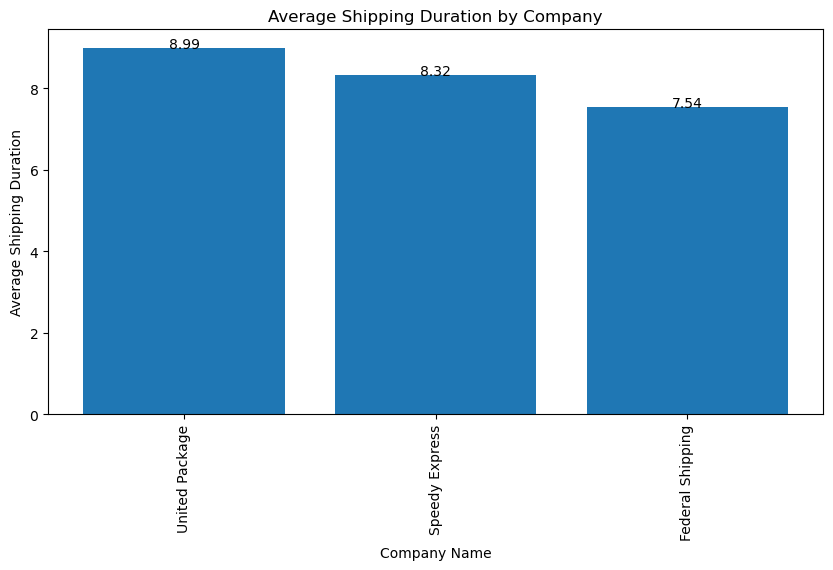

In [7]:
plt.figure(figsize=(10,5))
plt.bar(data_grouped.index, data_grouped['ship_duration'])
plt.xticks(rotation=90)
plt.ylabel('Average Shipping Duration')
plt.title('Average Shipping Duration by Company')
plt.xlabel('Company Name')

def addlabels(x,y):
    for i in range(len(x)):
        plt.text(i, y[i], y[i], ha = 'center')

x = data_grouped.index
y = data_grouped['ship_duration'].round(2)
addlabels(x, y)

In [8]:
data['revenue'] = data['unit_price'] * data['quantity'] * (1 - data['discount'])
data_grouped_revenue = data.groupby('company_name').agg({'revenue': 'sum'})
data_grouped_revenue = data_grouped_revenue.sort_values(by='revenue', ascending=False)
data_grouped_revenue

,revenue
company_name,
United Package,533547.6340
Federal Shipping,383405.4680
Speedy Express,348839.9375


In [9]:
data_join = data_grouped.join(data_grouped_revenue)
data_join = data_join.reset_index()
data_join

,company_name,ship_duration,revenue
0,United Package,8.993842,533547.6340
1,Speedy Express,8.316038,348839.9375
2,Federal Shipping,7.544164,383405.4680


Text(0.5, 1.0, 'Revenue and Ship Duration by Shipping Company')

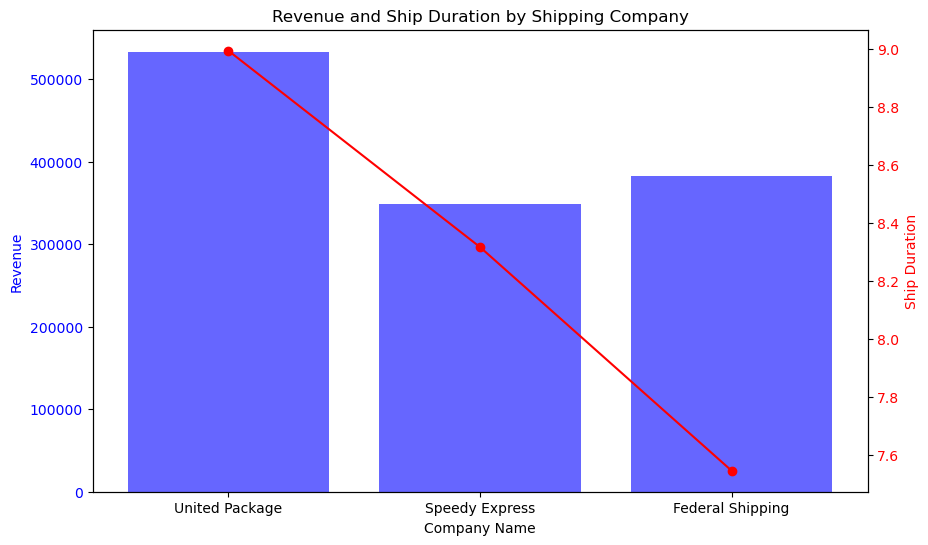

In [12]:
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.bar(data_join['company_name'], data_join['revenue'], color='b', alpha=0.6, label='Revenue')
ax1.set_xlabel('Company Name')
ax1.set_ylabel('Revenue', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax2 = ax1.twinx()
ax2.plot(data_join['company_name'], data_join['ship_duration'], color='r', marker='o', label='Ship Duration')
ax2.set_ylabel('Ship Duration', color='r')
ax2.tick_params(axis='y', labelcolor='r')
plt.title('Revenue and Ship Duration by Shipping Company')